In [1]:
import numpy as np
import torch; import torch.nn.functional as F
import matplotlib.pyplot as plt
import sys; sys.path.append("..")

from pathlib import Path
from utils.fetch import mnist
from utils import helpers
from src import nn
from tqdm import trange

---

## *MNIST Splits*

In [2]:
folder_path = 'C:\\Users\\alexr\\CodeFun\\miniAI\\data'
trainset, testset = mnist(folder_path)
x_train, y_train = trainset[0].reshape(-1, 28*28), trainset[1]
x_test, y_test = testset[0].reshape(-1, 28*28), testset[1]

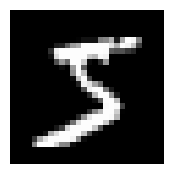

In [3]:
plt.figure(figsize=(2, 2))
plt.imshow(x_train[0].reshape(28, 28), cmap='gray');plt.axis(False);

## *Training Model*

In [4]:
n, m = x_train.shape
c = y_train.max()+1
nh = 32

In [5]:
class Model(nn.Module):

    def __init__(self, n_inp, n_hidden, n_out):
        super().__init__()
        self.layers = [nn.Linear(n_inp, n_hidden), nn.ReLU(), nn.Linear(n_hidden, n_out)]
        self.loss = nn.Cross_Entropy()

    def forward(self, x):
        for l in self.layers:
            x = l(x)
        return x

    def backward(self):
        out_grad = self.loss.backward()
        for l in reversed(self.layers):
            out_grad = l.backward(out_grad)

    def step(self, lr):
        for l in self.layers:
            if hasattr(l, 'weights'):
                l.update(lr)

In [6]:
model = Model(m, nh, c)
pred = model(x_train)

print('Custom: ', model.loss(pred, y_train))
print('Torch: ', F.cross_entropy(torch.tensor(pred), torch.tensor(y_train)).item())

Custom:  148.55696132341515
Torch:  148.55696132341518


In [7]:
pred[0]

array([ 137.89385448,   95.90901783,   99.90242207, -170.05360661,
        -75.59274556,  -62.67880037, -148.79362176,    2.77839039,
         62.32316733,   49.30277083])

In [8]:
bs = 64
lr = 0.001
epochs = 3

In [9]:
for epoch in trange(epochs):
    for i in range(0, n, bs):
        s = slice(i, min(n, i+bs))
        xb, yb = x_train[s], y_train[s]
        preds = model(xb)
        loss = model.loss(preds, yb)
        model.backward()
        model.step(lr)
    helpers.report(loss, preds, yb)

 33%|████████████████████████████                                                        | 1/3 [00:00<00:01,  1.47it/s]

1.64, 0.38


 67%|████████████████████████████████████████████████████████                            | 2/3 [00:01<00:00,  1.46it/s]

1.17, 0.59


100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:02<00:00,  1.37it/s]

1.04, 0.62


## *Parameters*

In [10]:
m1 = nn.Module()

In [11]:
m1.foo = nn.Linear(3,4)

In [12]:
m1.foo

Linear(in_features=3, out_features=4, bias=True)

In [13]:
m1.foo.parameters()

[]

In [14]:
class MLP(nn.Module):
    def __init__(self, n_inp, n_hidden, n_out):
        super().__init__()
        self.l1 = nn.Linear(n_inp, n_hidden)
        self.l2 = nn.Linear(n_hidden, n_out)
        self.l3 = nn.ReLU()

    def forward(self, x):
        return self.l2(self.relu(self.l1(x)))

In [15]:
mdl = MLP(m, nh, 10)
mdl

MLP(
)

In [16]:
from functools import reduce

class Model_Reg(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = layers
        for i, l in enumerate(self.layers):
            self.add_module(l)

    def forward(self, x):
        return reduce(lambda v, l: l(v), self.layers, x)

In [17]:
layers = [nn.Linear(m, nh), nn.ReLU(), nn.Linear(nh, c)]
mdl = Model_Reg(layers)

In [18]:
mdl

Model_Reg(
  (0): Linear(in_features=784, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=10, bias=True)
)

In [19]:
mdl.forward(x_train).shape

(60000, 10)

In [20]:
model = nn.Sequential([nn.Linear(m,nh), nn.ReLU(), nn.Linear(nh,10)])

In [21]:
model

Sequential(
  (0): [Linear(in_features=784, out_features=32, bias=True), ReLU(), Linear(in_features=32, out_features=10, bias=True)]
)

In [22]:
model(x_train).shape

TypeError: 'list' object is not callable